# Análisis de Hiperparámetros - Práctica 2 (RL IMAT)

Apartado 4 y 5: Análisis de convergencia de SARSA y Q-learning para distintos valores de:
- **Número de episodios** (500, 2000, 5000, 20000)
- **Tasa de aprendizaje α** (0.01, 0.1, 0.5, 1.0)
- **Exploración ε** (0, 0.05, 0.2, 0.5)
- **Inicialización Q₀** (-10, 0, 5, 20)

## 1. Configuración

In [1]:
ALGORITMOS = ['sarsa', 'q_learning']
SEMILLAS = list(range(5))
TRACK_STATES = (6, 13)
R_STEP, R_OBSTACLE, R_GOAL = -1.0, -5.0, 5.0
GAMMA = 0.9
BASE = {'episodes': 5000, 'alpha': 0.1, 'epsilon': 0.2, 'q_init': 0.0}
BARRIDOS = {
    'episodes': [500, 2000, 5000, 20000],
    'alpha': [0.01, 0.1, 0.5, 1.0],
    'epsilon': [0.0, 0.05, 0.2, 0.5],
    'q_init': [-10, 0, 5, 20],
}
VENTANA_RESUMEN = 200
print(f'Config: {len(ALGORITMOS)} algoritmos × {len(SEMILLAS)} semillas × 4 barridos × 4 valores = {len(ALGORITMOS) * len(SEMILLAS) * 16} entrenamientos')

Config: 2 algoritmos × 5 semillas × 4 barridos × 4 valores = 160 entrenamientos


## 2. Imports

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str((Path('..') / 'src').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium.envs.registration import register
from collections import defaultdict
import time
import pandas as pd

from env import INITIAL_STATES, N_NON_TERMINAL, TERMINAL_STATE, CELL_TO_STATE, STATE_TO_CELL
from sarsa import sarsa, greedy_policy, epsilon_greedy
from q_learning import q_learning

ACTION_NAME = {0: 'arriba-derecha', 1: 'abajo-derecha'}
ACTION_SYMBOL = {0: '↗', 1: '↘'}

print('✓ Imports OK')

✓ Imports OK


## 3. Entorno y q* óptima

In [3]:
register(id='JumpToTheGoalEnv-v0', entry_point='env:JumpToTheGoalEnv')
env = gym.make('JumpToTheGoalEnv-v0', deterministic=True, r_step=R_STEP, r_obstacle=R_OBSTACLE, r_goal=R_GOAL, initial_state=None)

def compute_q_star(P, gamma, max_iters=1000, tol=1e-6):
    nS = len(P)
    nA = len(P[0])
    V = np.zeros(nS)
    Q_star = np.zeros((nS, nA))
    for iteration in range(max_iters):
        V_old = V.copy()
        for s in range(nS):
            for a in range(nA):
                q_sa = sum(prob * (reward + gamma * (0 if terminated else V_old[s_prime])) for prob, s_prime, reward, terminated in P[s][a])
                Q_star[s, a] = q_sa
            V[s] = np.max(Q_star[s])
        if np.max(np.abs(V - V_old)) < tol:
            print(f'Value iteration convergió en {iteration+1} iteraciones')
            break
    return Q_star, V

P = env.unwrapped.P
Q_star, V_star = compute_q_star(P, GAMMA)
pi_star = greedy_policy(Q_star)
print(f'✓ q*(s,a) calculada')

Value iteration convergió en 6 iteraciones
✓ q*(s,a) calculada


## 4. Entrenamientos

In [4]:
def corre_entrenamiento(alg_name, episodes, alpha, gamma, epsilon, q_init, seed):
    if alg_name == 'sarsa':
        return sarsa(env, episodes, alpha, gamma, epsilon, q_init=q_init, seed=seed, track_states=TRACK_STATES)
    else:
        return q_learning(env, episodes, alpha, gamma, epsilon, q_init=q_init, seed=seed, track_states=TRACK_STATES)

res = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
total_entrenamientos = len(ALGORITMOS) * len(SEMILLAS) * sum(len(v) for v in BARRIDOS.values())
contador, inicio = 0, time.time()

print(f'Ejecutando {total_entrenamientos} entrenamientos...\n')

for alg in ALGORITMOS:
    for param_name, valores in BARRIDOS.items():
        for valor in valores:
            hp = BASE.copy()
            hp[param_name] = valor
            for seed in SEMILLAS:
                contador += 1
                resultado = corre_entrenamiento(alg, int(hp['episodes']), hp['alpha'], GAMMA, hp['epsilon'], hp['q_init'], seed)
                res[alg][param_name][valor].append(resultado)
                elapsed = time.time() - inicio
                pct = 100 * contador / total_entrenamientos
                eta = elapsed / (contador + 1e-6) * (total_entrenamientos - contador)
                print(f'[{pct:5.1f}%] {alg:10s} {param_name:10s}={str(valor):8s} seed={seed} ({elapsed:.0f}s, ETA {eta:.0f}s)', end='\r')

elapsed = time.time() - inicio
print(f'\n✓ Entrenamientos completados en {elapsed/60:.1f} minutos')

Ejecutando 160 entrenamientos...

[100.0%] q_learning q_init    =20       seed=4 (60s, ETA 0s)))
✓ Entrenamientos completados en 1.0 minutos


## 5. GRÁFICAS

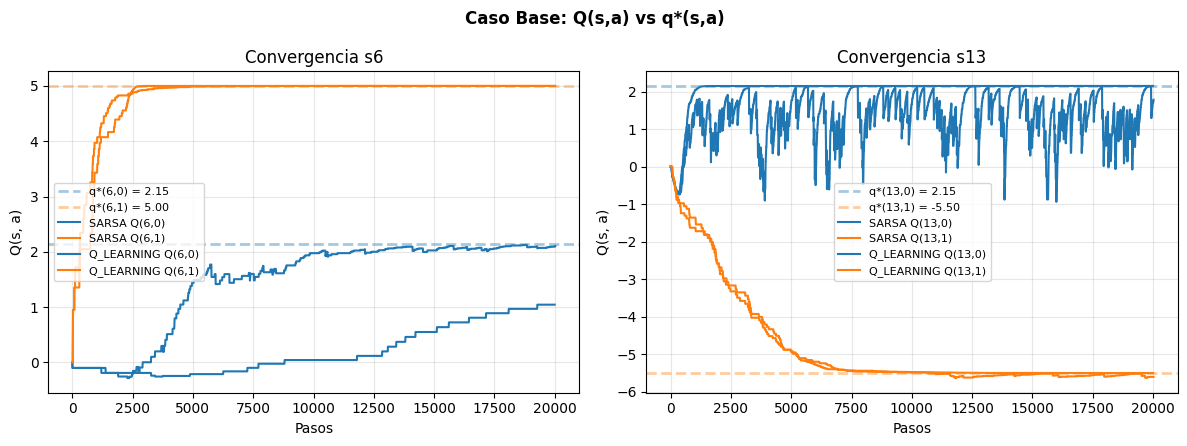

✓ 01_caso_base.png


In [5]:
# 01_caso_base.png
def get_base_results():
    base_res = {}
    for alg in ALGORITMOS:
        for param_name, valor in BASE.items():
            resultados_param = res[alg][param_name].get(valor, [])
            if resultados_param:
                base_res[alg] = resultados_param[0]
                break
    return base_res

base_results = get_base_results()
fig, axes = plt.subplots(1, len(TRACK_STATES), figsize=(12, 4.5))
if len(TRACK_STATES) == 1:
    axes = [axes]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for ax_idx, state in enumerate(TRACK_STATES):
    ax = axes[ax_idx]
    for action in range(2):
        ax.axhline(Q_star[state, action], color=colors[action], linestyle='--', linewidth=2, alpha=0.4, label=f'q*({state},{action}) = {Q_star[state, action]:.2f}')
    for alg in ALGORITMOS:
        if alg in base_results:
            resultado = base_results[alg]
            track_idx = TRACK_STATES.index(state)
            for action in range(2):
                q_vals = resultado['q_history'][:, track_idx, action]
                pasos = resultado['pasos_acumulados']
                ax.plot(pasos, q_vals, color=colors[action], linewidth=1.5, label=f'{alg.upper()} Q({state},{action})')
    ax.set_xlabel('Pasos')
    ax.set_ylabel('Q(s, a)')
    ax.set_title(f'Convergencia s{state}')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best')

fig.suptitle('Caso Base: Q(s,a) vs q*(s,a)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('01_caso_base.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ 01_caso_base.png')

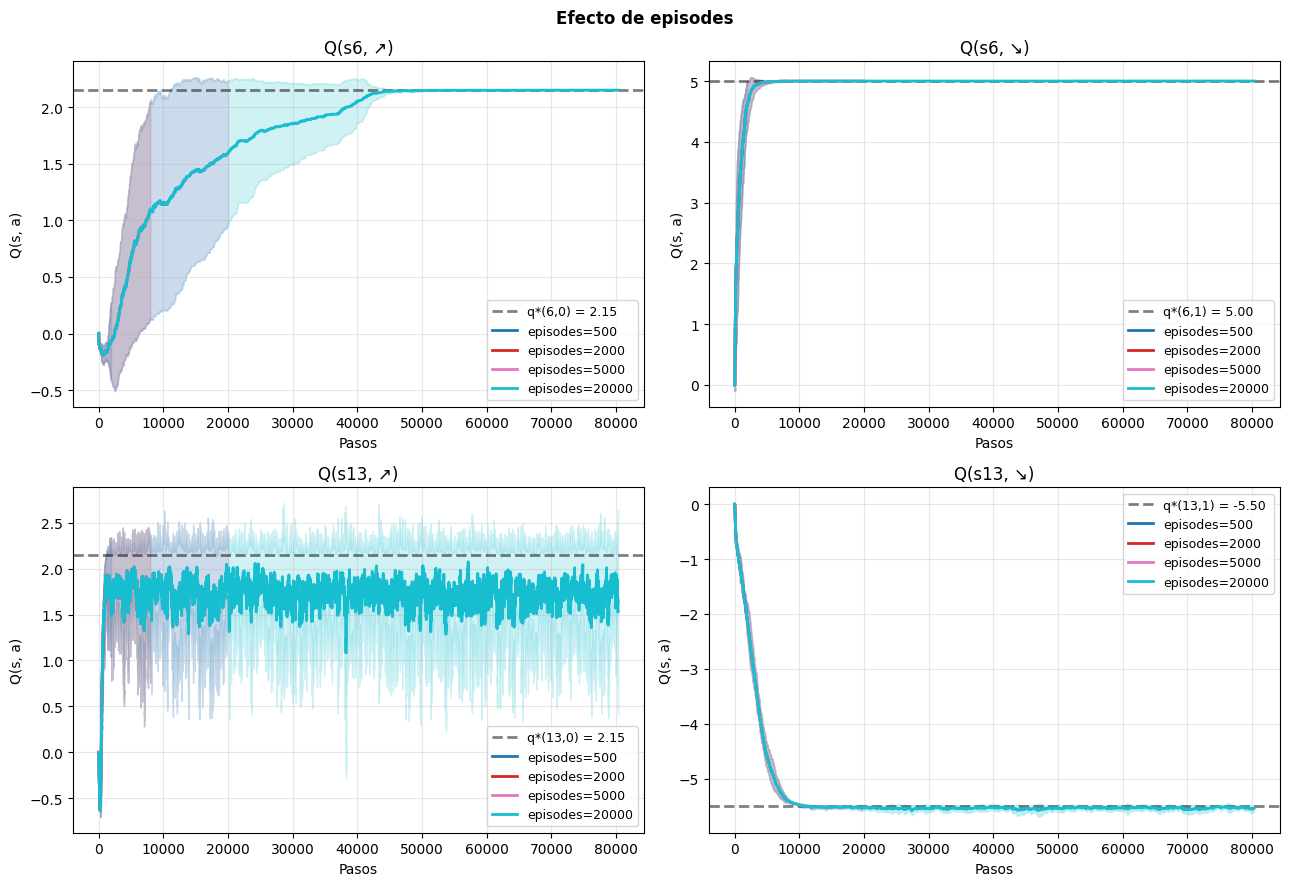

✓ 02_episodes.png


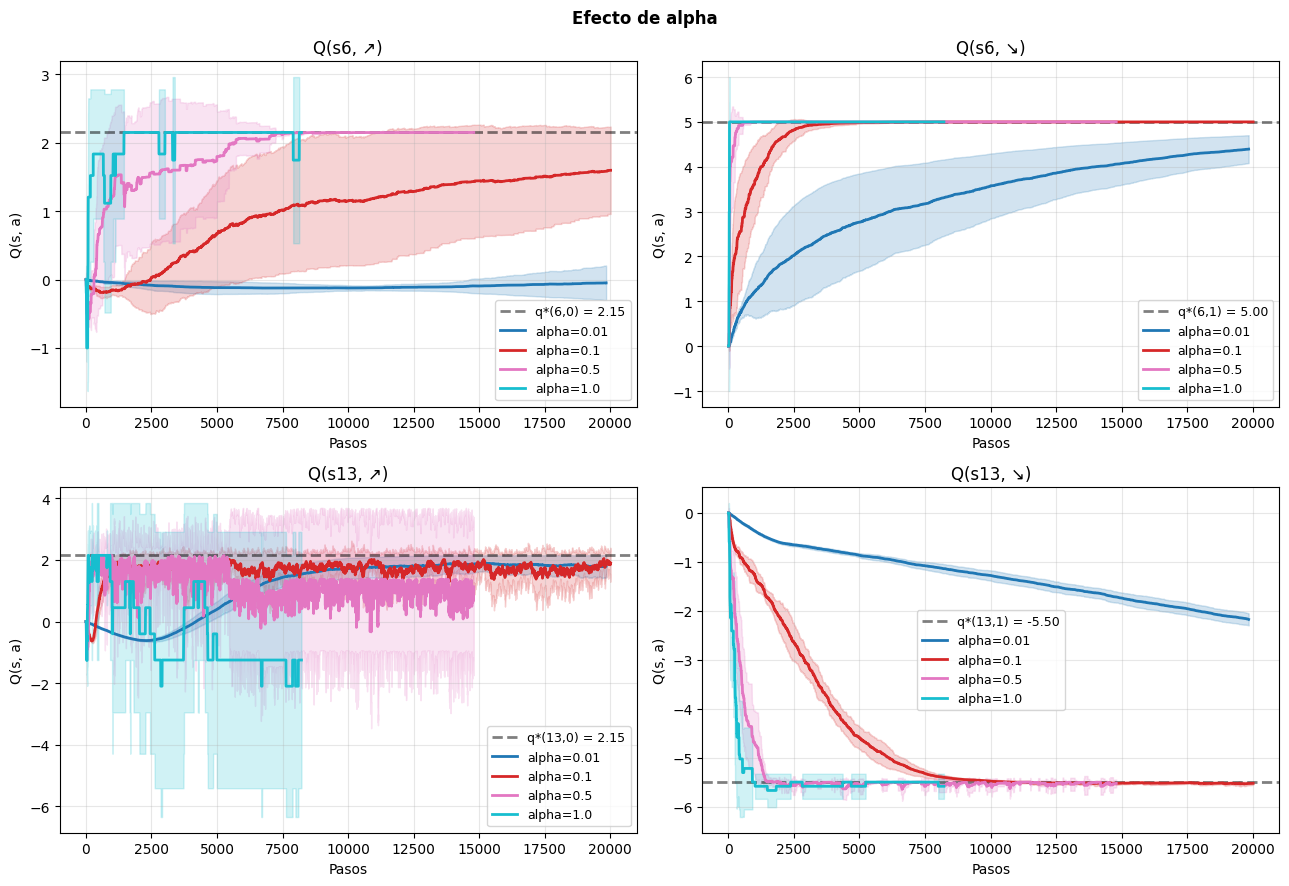

✓ 02_alpha.png


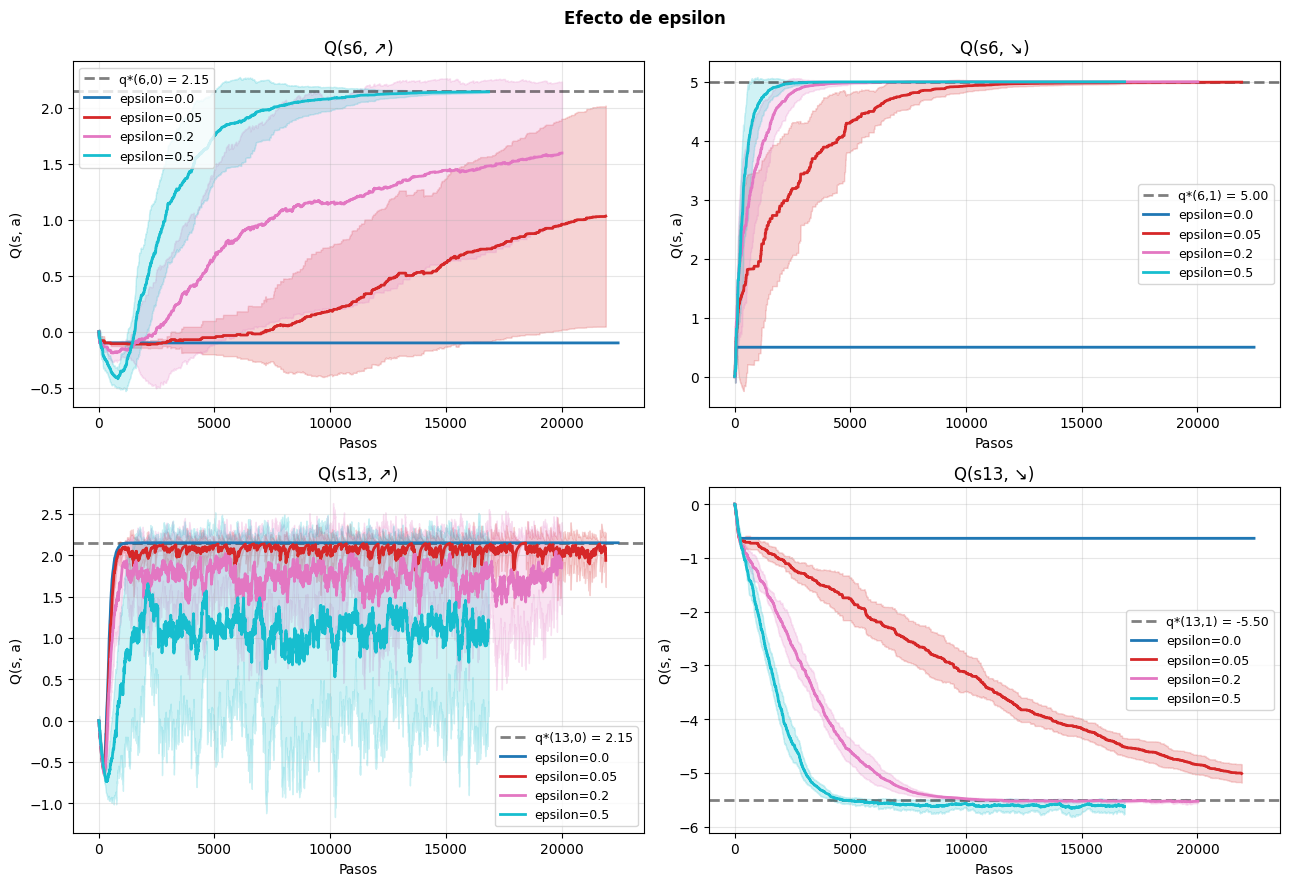

✓ 02_epsilon.png


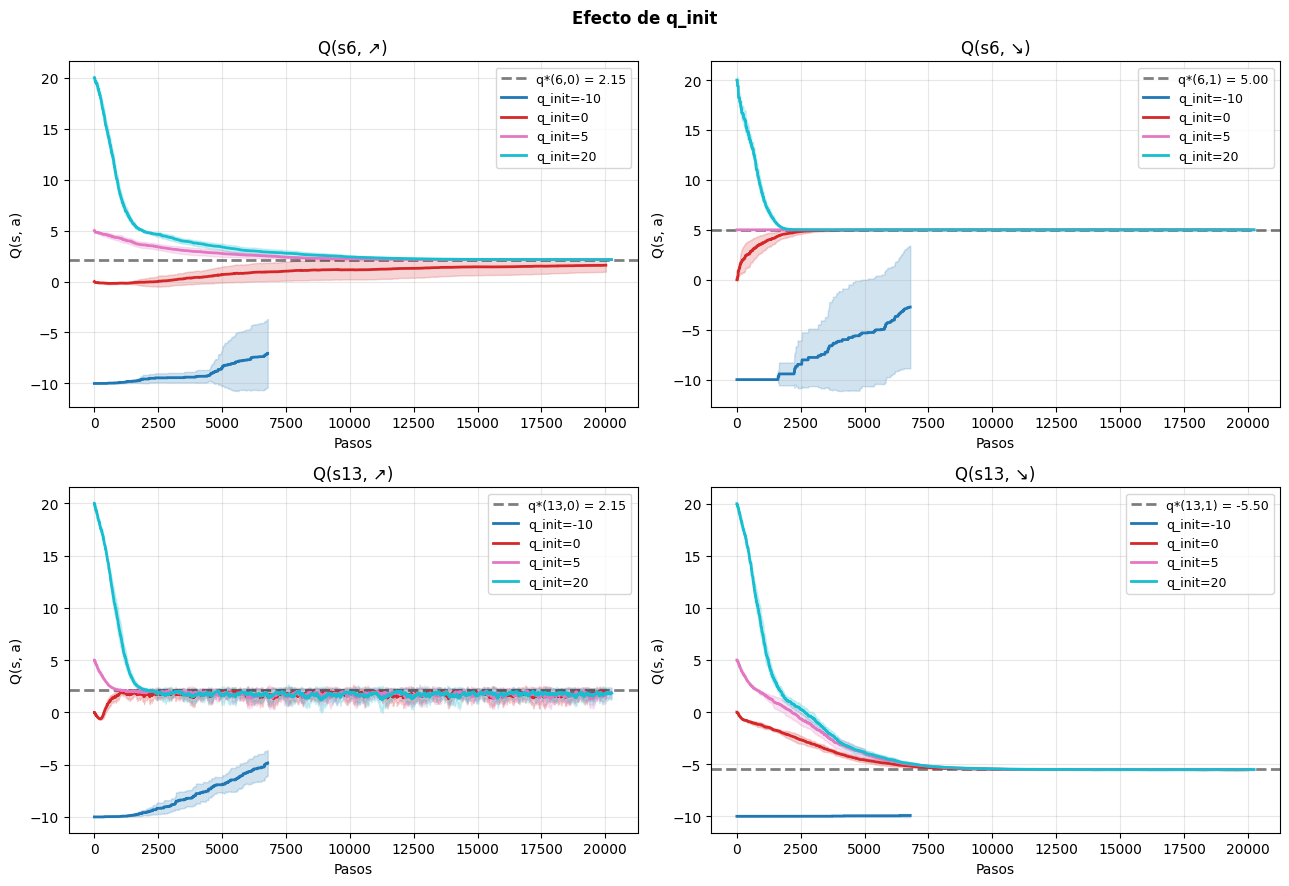

✓ 02_q_init.png


In [6]:
# 02_episodes.png, 02_alpha.png, 02_epsilon.png, 02_q_init.png
def plot_hyperparameter_effect(param_name):
    valores = BARRIDOS[param_name]
    fig, axes = plt.subplots(len(TRACK_STATES), 2, figsize=(13, 4.5 * len(TRACK_STATES)), squeeze=False)
    
    for row_idx, state in enumerate(TRACK_STATES):
        track_idx = TRACK_STATES.index(state)
        for action in range(2):
            ax = axes[row_idx, action]
            ax.axhline(Q_star[state, action], color='black', linestyle='--', linewidth=2, alpha=0.5, label=f'q*({state},{action}) = {Q_star[state, action]:.2f}')
            palette = plt.cm.tab10(np.linspace(0, 1, len(valores)))
            
            for valor_idx, valor in enumerate(valores):
                color = palette[valor_idx]
                q_vals_all_seeds, pasos_ref = [], None
                for alg in ALGORITMOS:
                    for resultado in res[alg][param_name].get(valor, []):
                        q_vals_all_seeds.append(resultado['q_history'][:, track_idx, action])
                        if pasos_ref is None:
                            pasos_ref = resultado['pasos_acumulados']
                
                if q_vals_all_seeds:
                    q_vals_all_seeds = np.array(q_vals_all_seeds)
                    q_mean = np.mean(q_vals_all_seeds, axis=0)
                    q_std = np.std(q_vals_all_seeds, axis=0)
                    ax.plot(pasos_ref, q_mean, color=color, linewidth=2, label=f'{param_name}={valor}')
                    ax.fill_between(pasos_ref, q_mean - q_std, q_mean + q_std, color=color, alpha=0.2)
            
            ax.set_xlabel('Pasos')
            ax.set_ylabel('Q(s, a)')
            ax.set_title(f'Q(s{state}, {ACTION_SYMBOL[action]})')
            ax.grid(alpha=0.3)
            ax.legend(fontsize=9, loc='best')
    
    fig.suptitle(f'Efecto de {param_name}', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig(f'02_{param_name}.png', dpi=100, bbox_inches='tight')
    plt.show()
    print(f'✓ 02_{param_name}.png')

for param_name in BARRIDOS.keys():
    plot_hyperparameter_effect(param_name)

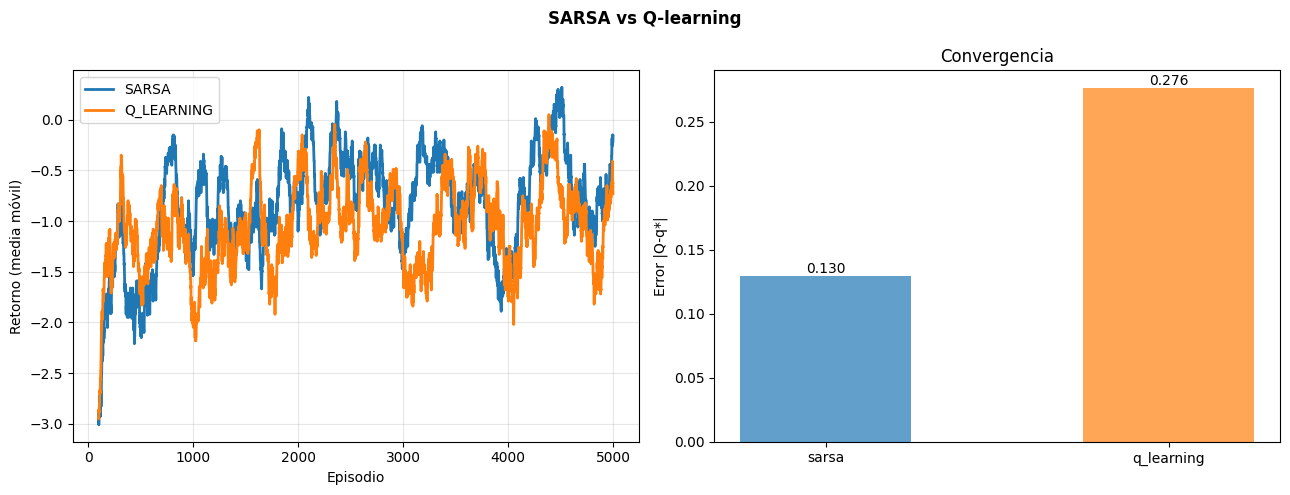

✓ 03_comparacion_algoritmos.png


In [7]:
# 03_comparacion_algoritmos.png
if len(ALGORITMOS) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    ax = axes[0]
    for alg in ALGORITMOS:
        if alg in base_results:
            resultado = base_results[alg]
            window = 100
            retornos = resultado['retornos']
            retornos_smooth = np.convolve(retornos, np.ones(window)/window, mode='valid')
            episodios = np.arange(window-1, len(retornos))
            ax.plot(episodios, retornos_smooth, linewidth=2, label=alg.upper())
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Retorno (media móvil)')
    ax.legend()
    ax.grid(alpha=0.3)
    
    ax = axes[1]
    errors_per_alg = {}
    for alg in ALGORITMOS:
        if alg in base_results:
            q_final = base_results[alg]['Q']
            errors = [abs(q_final[s, a] - Q_star[s, a]) for s in TRACK_STATES for a in range(2)]
            errors_per_alg[alg] = np.mean(errors)
    
    algs = list(errors_per_alg.keys())
    errors = [errors_per_alg[alg] for alg in algs]
    bars = ax.bar(algs, errors, width=0.5, alpha=0.7, color=['#1f77b4', '#ff7f0e'][:len(algs)])
    ax.set_ylabel('Error |Q-q*|')
    ax.set_title('Convergencia')
    for bar, error in zip(bars, errors):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(), f'{error:.3f}', ha='center', va='bottom')
    
    fig.suptitle('SARSA vs Q-learning', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('03_comparacion_algoritmos.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('✓ 03_comparacion_algoritmos.png')

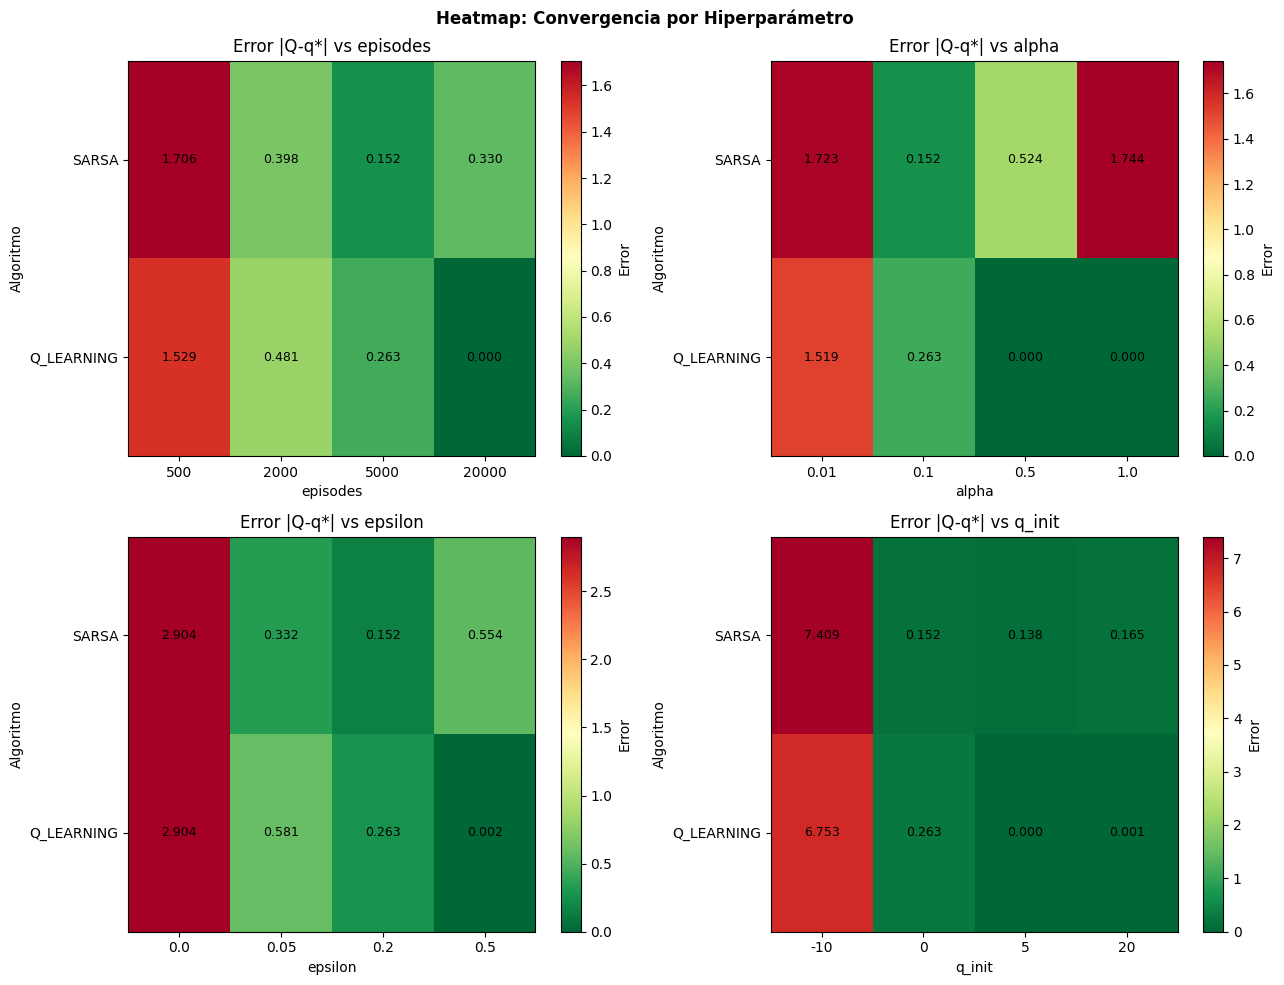

✓ 04_heatmap_errores.png


In [8]:
# 04_heatmap_errores.png
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax_idx, param_name in enumerate(BARRIDOS.keys()):
    ax = axes[ax_idx]
    valores = BARRIDOS[param_name]
    heatmap_data = np.zeros((len(ALGORITMOS), len(valores)))
    
    for alg_idx, alg in enumerate(ALGORITMOS):
        for val_idx, valor in enumerate(valores):
            resultados_semillas = res[alg][param_name].get(valor, [])
            if resultados_semillas:
                errors = []
                for r in resultados_semillas:
                    q_final = r['Q']
                    for s in TRACK_STATES:
                        for a in range(2):
                            errors.append(abs(q_final[s, a] - Q_star[s, a]))
                heatmap_data[alg_idx, val_idx] = np.mean(errors)
    
    im = ax.imshow(heatmap_data, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=np.max(heatmap_data))
    ax.set_xticks(range(len(valores)))
    ax.set_yticks(range(len(ALGORITMOS)))
    ax.set_xticklabels([str(v) for v in valores])
    ax.set_yticklabels([a.upper() for a in ALGORITMOS])
    ax.set_xlabel(param_name)
    ax.set_ylabel('Algoritmo')
    ax.set_title(f'Error |Q-q*| vs {param_name}')
    
    for i in range(len(ALGORITMOS)):
        for j in range(len(valores)):
            ax.text(j, i, f'{heatmap_data[i, j]:.3f}', ha='center', va='center', color='black', fontsize=9)
    
    plt.colorbar(im, ax=ax, label='Error')

fig.suptitle('Heatmap: Convergencia por Hiperparámetro', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('04_heatmap_errores.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ 04_heatmap_errores.png')

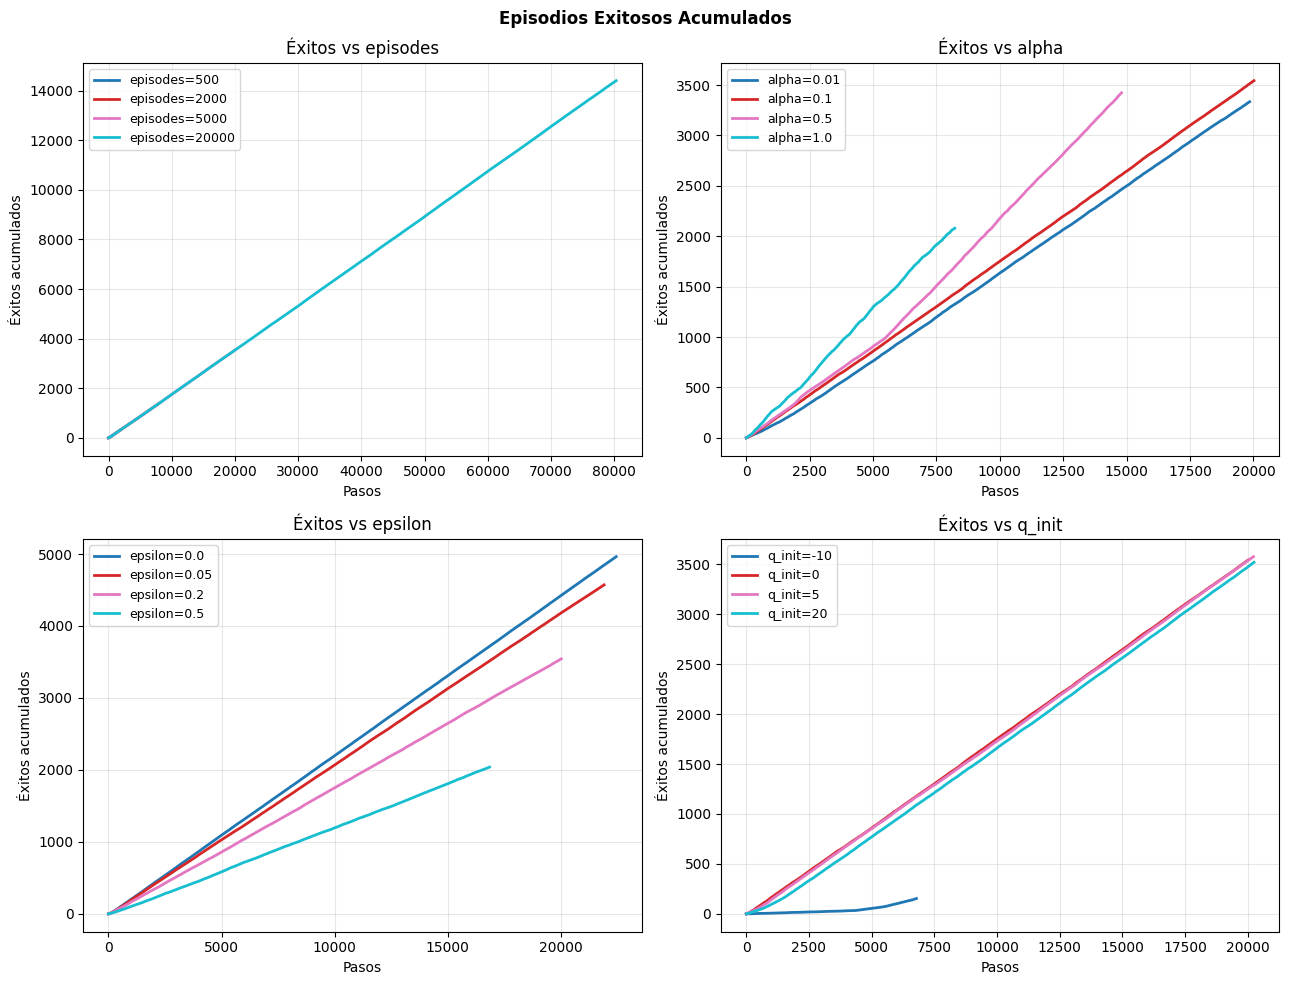

✓ 05_exitos_acumulados.png


In [9]:
# 05_exitos_acumulados.png
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax_idx, param_name in enumerate(BARRIDOS.keys()):
    ax = axes[ax_idx]
    valores = BARRIDOS[param_name]
    palette = plt.cm.tab10(np.linspace(0, 1, len(valores)))
    
    for valor_idx, valor in enumerate(valores):
        color = palette[valor_idx]
        exitos_all, pasos_ref = [], None
        for alg in ALGORITMOS:
            for resultado in res[alg][param_name].get(valor, []):
                exitos_all.append(resultado['exitos'])
                if pasos_ref is None:
                    pasos_ref = resultado['pasos_acumulados']
        
        if exitos_all:
            exitos_all = np.array(exitos_all)
            exitos_mean = np.mean(exitos_all, axis=0)
            exitos_acum = np.cumsum(exitos_mean)
            ax.plot(pasos_ref, exitos_acum, linewidth=2, color=color, label=f'{param_name}={valor}')
    
    ax.set_xlabel('Pasos')
    ax.set_ylabel('Éxitos acumulados')
    ax.set_title(f'Éxitos vs {param_name}')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)

fig.suptitle('Episodios Exitosos Acumulados', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('05_exitos_acumulados.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ 05_exitos_acumulados.png')

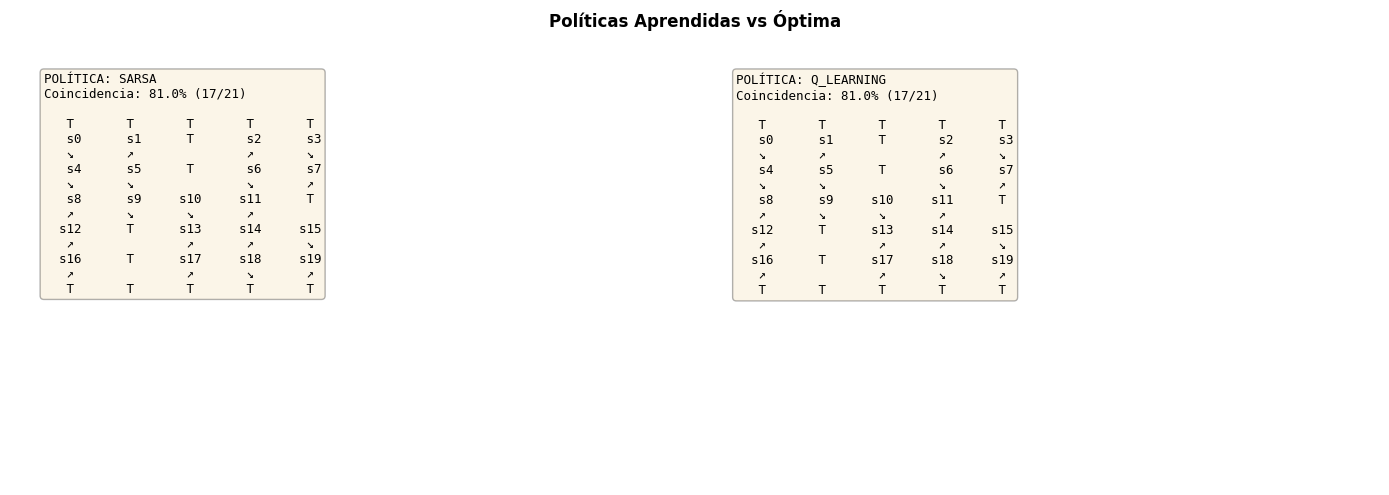

✓ 06_politicas_finales.png


In [10]:
# 06_politicas_finales.png
def grid_layout_policy(desc, politica):
    CELL_WIDTH = 8
    nrow, ncol = desc.shape
    lineas = []
    for row in range(nrow):
        etiquetas, acciones = [], []
        for col in range(ncol):
            cell = row * ncol + col
            if cell in CELL_TO_STATE:
                estado = CELL_TO_STATE[cell]
                etiquetas.append(f's{estado}'.center(CELL_WIDTH))
                acciones.append(ACTION_SYMBOL[int(politica[estado])].center(CELL_WIDTH))
            else:
                etiquetas.append('T'.center(CELL_WIDTH))
                acciones.append(''.center(CELL_WIDTH))
        lineas.append(''.join(etiquetas).rstrip())
        if ''.join(acciones).strip():
            lineas.append(''.join(acciones).rstrip())
    return '\n'.join(lineas)

fig = plt.figure(figsize=(14, 5))
base_res = get_base_results()

for plot_idx, (nombre, resultado) in enumerate(base_res.items()):
    ax = fig.add_subplot(1, 2, plot_idx + 1)
    ax.axis('off')
    
    q_final = resultado['Q']
    politica_aprendida = greedy_policy(q_final)
    politica_opt = greedy_policy(Q_star)
    aciertos = np.sum(politica_aprendida == politica_opt)
    total = len(politica_aprendida)
    pct_acierto = 100 * aciertos / total
    
    texto = f'POLÍTICA: {nombre.upper()}\nCoincidencia: {pct_acierto:.1f}% ({aciertos}/{total})\n\n'
    texto += grid_layout_policy(env.unwrapped.desc, politica_aprendida)
    
    ax.text(0.05, 0.95, texto, transform=ax.transAxes, fontsize=9, verticalalignment='top', fontfamily='monospace',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('Políticas Aprendidas vs Óptima', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('06_politicas_finales.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ 06_politicas_finales.png')

C:\Temp\Win\ipykernel_14016\2519863597.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_plot, labels=labels_for_plot, patch_artist=True)
C:\Temp\Win\ipykernel_14016\2519863597.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_plot, labels=labels_for_plot, patch_artist=True)
C:\Temp\Win\ipykernel_14016\2519863597.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_plot, labels=labels_for_plot, patch_artist=True)
C:\Temp\Win\ipykernel_14016\2519863597.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been rename

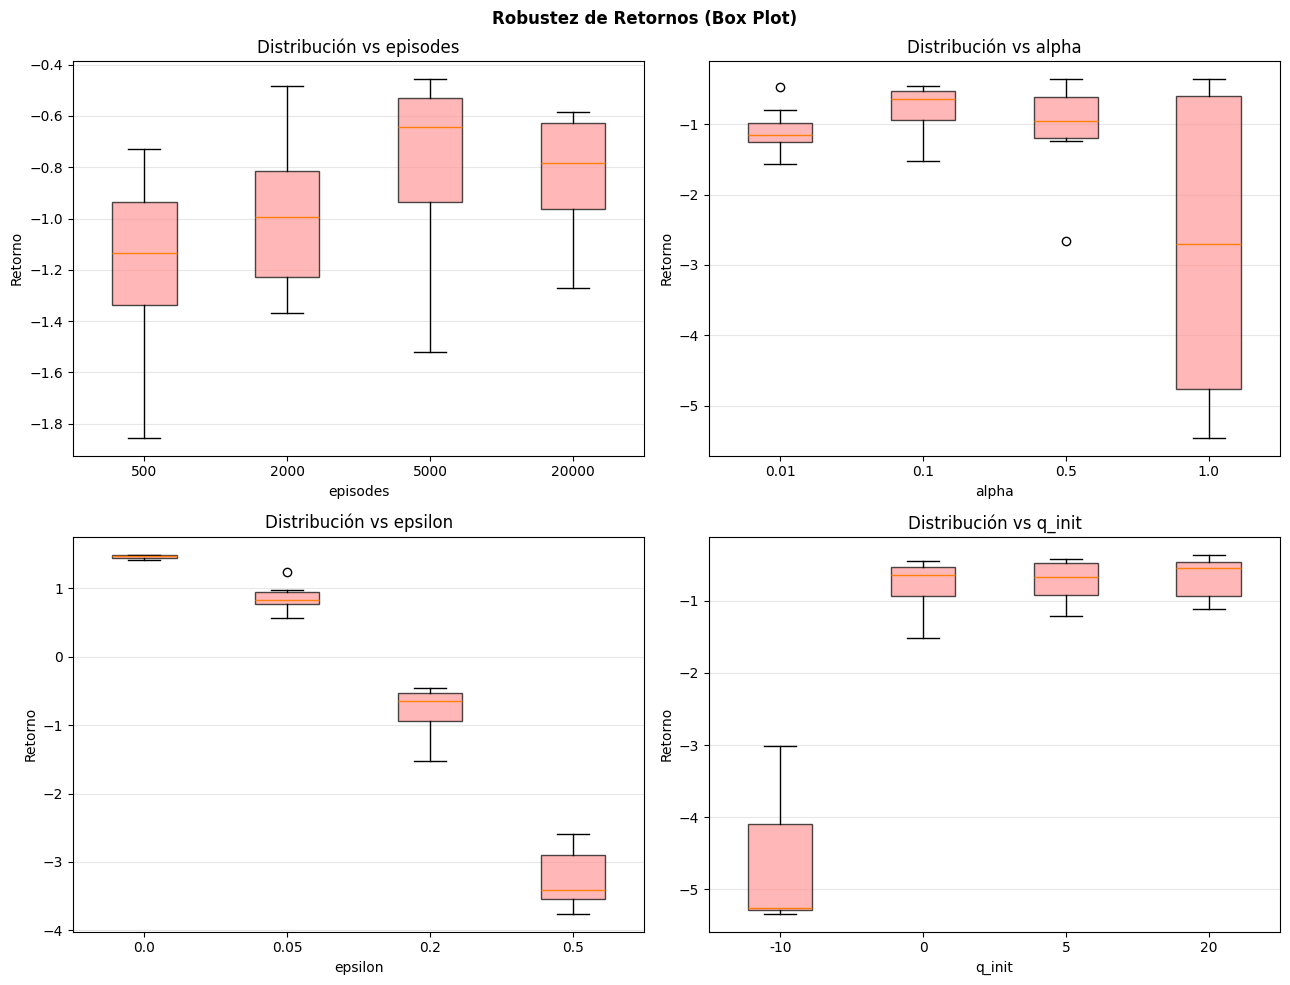

✓ 07_distribucion_retornos.png


In [11]:
# 07_distribucion_retornos.png
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax_idx, param_name in enumerate(BARRIDOS.keys()):
    ax = axes[ax_idx]
    valores = BARRIDOS[param_name]
    data_for_plot, labels_for_plot = [], []
    
    for valor in valores:
        retornos_all = []
        for alg in ALGORITMOS:
            for resultado in res[alg][param_name].get(valor, []):
                retorno_promedio = np.mean(resultado['retornos'][-VENTANA_RESUMEN:])
                retornos_all.append(retorno_promedio)
        data_for_plot.append(retornos_all)
        labels_for_plot.append(str(valor))
    
    bp = ax.boxplot(data_for_plot, labels=labels_for_plot, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#ff9999')
        patch.set_alpha(0.7)
    
    ax.set_xlabel(param_name)
    ax.set_ylabel('Retorno')
    ax.set_title(f'Distribución vs {param_name}')
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Robustez de Retornos (Box Plot)', fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('07_distribucion_retornos.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ 07_distribucion_retornos.png')

## 6. Conclusiones

In [12]:
print("""\n✓ TODAS LAS GRÁFICAS GENERADAS (10 total):
  01_caso_base.png
  02_episodes.png, 02_alpha.png, 02_epsilon.png, 02_q_init.png
  03_comparacion_algoritmos.png
  04_heatmap_errores.png
  05_exitos_acumulados.png
  06_politicas_finales.png
  07_distribucion_retornos.png
""")


✓ TODAS LAS GRÁFICAS GENERADAS (10 total):
  01_caso_base.png
  02_episodes.png, 02_alpha.png, 02_epsilon.png, 02_q_init.png
  03_comparacion_algoritmos.png
  04_heatmap_errores.png
  05_exitos_acumulados.png
  06_politicas_finales.png
  07_distribucion_retornos.png

